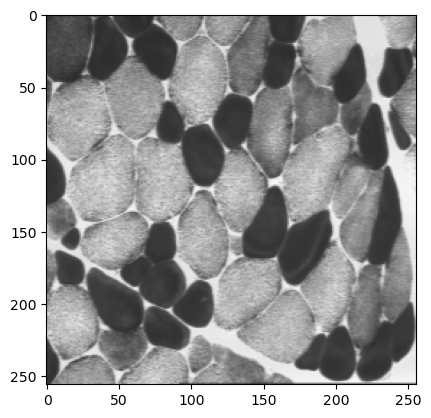

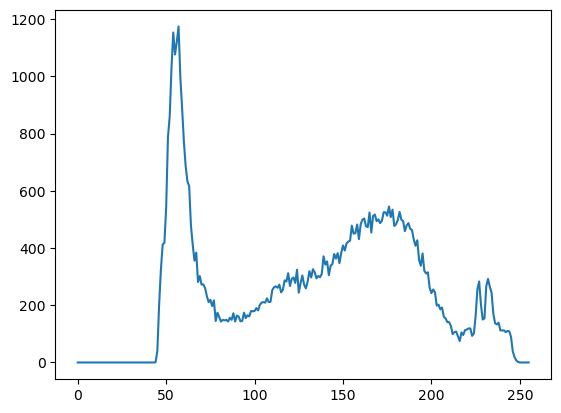

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

image = cv2.imread("images/MUSCLE.png", cv2.IMREAD_GRAYSCALE)

# Visualizar imagen
plt.imshow(image, cmap="gray",  vmin=0, vmax=255)
plt.show()

# Visualizar histograma
hist = cv2.calcHist([image],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

Visualice su histograma y escoja un valor S de nivel de gris que permita separar aproximadamente las fibras oscuras del resto de la imagen. ¿Cuál es este valor?

Ese valor podria ser el pico, S = 70 puede ser un candidato para separar los pixeles mas oscuros del resto

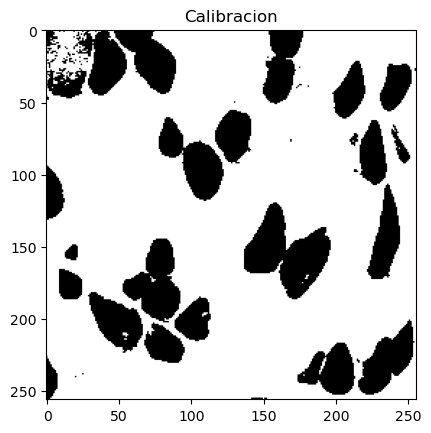

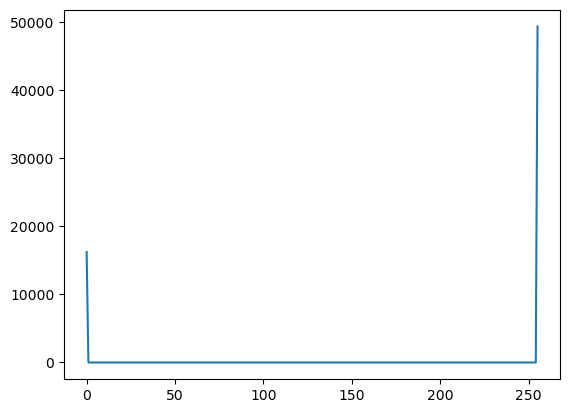

In [2]:
# Efectúe una calibración del histograma (ver primer punto de este taller) entre los valores S y S +1 de la imagen.
from skimage import exposure
# --- Calibrada ---
rescaled_img = exposure.rescale_intensity(image, in_range=(70,71), out_range=(0,255))

# Visualizar imagen
plt.imshow(rescaled_img, cmap="gray", vmin=0, vmax=255)
plt.title("Calibracion")
plt.show()

# Visualizar histograma
rescaled_img = rescaled_img.astype(np.uint8)
hist = cv2.calcHist([rescaled_img],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

Visualice la imagen resultado y su histograma. ¿Cuál es su conclusión?
El valor S = 70 actuó como un umbral, para separar pixeles oscuros y blancos. Al calibrarlo con un rango de 70 - 71, se vuelve una imagen de blanco y negro, todos los pixeles por debajo de 70 se vuelven negros y los pixeles por encima de 70 se vuelven blancos

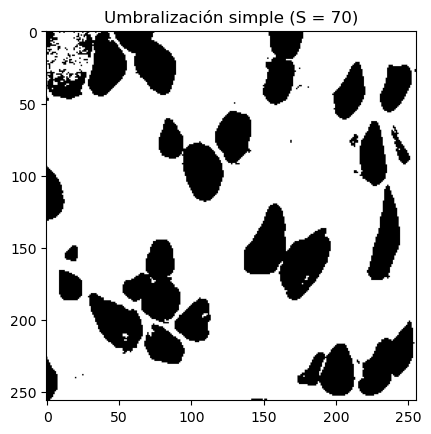

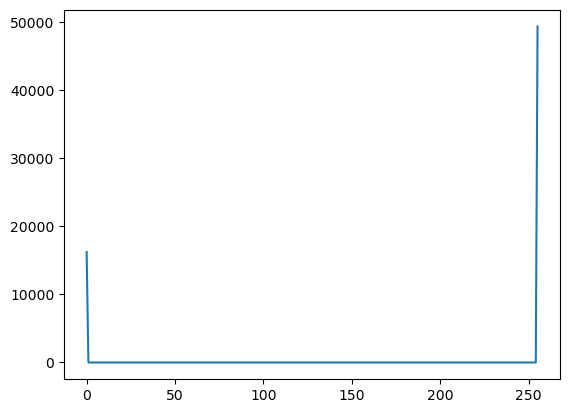

In [3]:
# Repita la misma operación utilizando el módulo de umbralización simple, con el umbral S.
S = 70

thres_value, thres_image = cv2.threshold(image, S, 255, cv2.THRESH_BINARY)

# Visualizar imagen
plt.imshow(thres_image, cmap='gray', vmin=0, vmax=255)
plt.title("Umbralización simple (S = 70)")
plt.show()

# Histograma
hist = cv2.calcHist([thres_image],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()


¿Conclusión?
Los resultados obtenidos mediante la calibración del histograma entre S y S+1 y mediante la umbralización simple con S son iguales. Esto significa que una calibración en un rango muy estrecho actúa como una umbralización, separando la imagen en dos clases de intensidad.

125.0


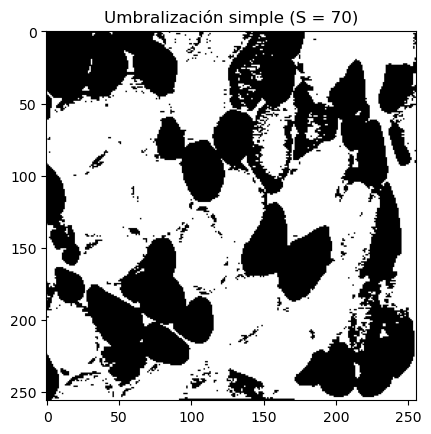

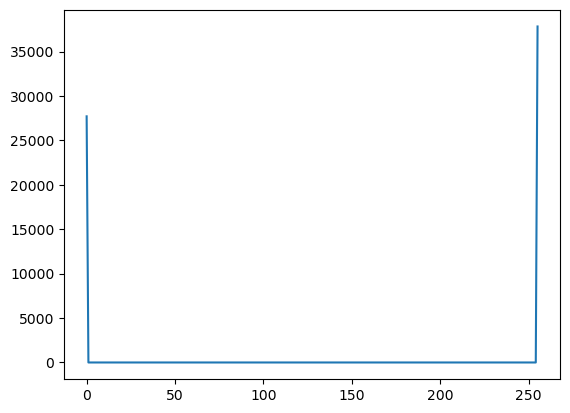

In [4]:
# ¿Qué resultado dan los métodos de umbralización automática (Otsu) basados sobre la varianza?
thres_value, thres_image = cv2.threshold(image, S, 255, cv2.THRESH_OTSU)
print(thres_value)

# Visualizar imagen
plt.imshow(thres_image, cmap='gray', vmin=0, vmax=255)
plt.title("Umbralización simple (S = 70)")
plt.show()

# Histograma
hist = cv2.calcHist([thres_image],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

¿Qué resultado dan los métodos de umbralización automática (Otsu) basados sobre la varianza? ¿Cómo eligen estos métodos el umbral a aplicar? Visualice las imágenes resultado y sus histogramas.

Este metodo, selecciona el umbral automaticamente, esto lo hace OpenCV mediante calculos matematicos para tener el umbral mas optimo.